In [2]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# random seed for reproducibility
np.random.seed(42)

In [3]:
	
# making test data for one SNP

N = 200

# minor allele frequencies
p_control = 0.2
p_case = 0.8

# simulating genotyes under HWE
snp_control = np.random.choice([0,1,2], size=int(N/2), p=[(1-p_control)**2, 2*p_control*(1-p_control), p_control**2])
snp_case = np.random.choice([0,1,2], size=int(N/2), p=[(1-p_case )**2, 2*p_case *(1-p_case ), p_case**2])

# combine
snp = np.concatenate([snp_control, snp_case])
labels = np.array([0]*100 + [1]*100)

In [4]:
print("Genotype shape:", snp.shape)
print("First couple genotypes:", snp[0:10])
print("Unique genotype values:", np.unique(snp))
print()
print("Labels shape:", labels.shape)
print("First couple lables:", labels[0:10])
print("Unique lable values:", np.unique(labels))

Genotype shape: (200,)
First couple genotypes: [0 1 1 0 0 0 0 1 0 1]
Unique genotype values: [0 1 2]

Labels shape: (200,)
First couple lables: [0 0 0 0 0 0 0 0 0 0]
Unique lable values: [0 1]


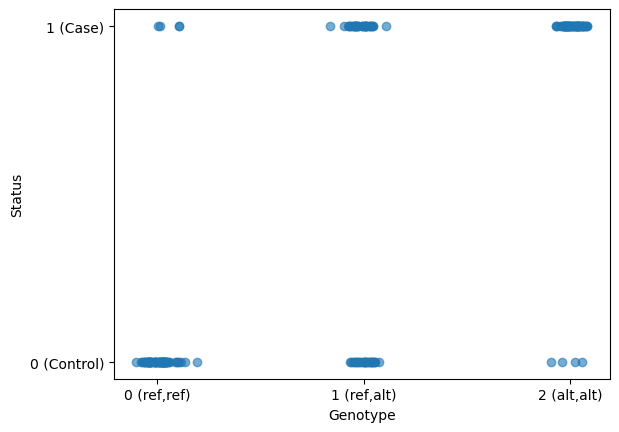

In [5]:
plt.figure()
# add small random noise for display
x_jitter = snp + np.random.normal(0, 0.05, size=N)
plt.scatter(x_jitter, labels, alpha=0.6)
plt.yticks([0,1], ["0 (Control)", "1 (Case)"])
plt.xticks([0,1,2], ["0 (ref,ref)", "1 (ref,alt)","2 (alt,alt)"])

plt.xlabel("Genotype")
plt.ylabel("Status")
plt.show()

In [6]:
# the logistic regression equation to fit to the data

def logistic(x, beta_0, beta_1):
    return 1 / (1 + np.exp(-(beta_0 + beta_1 * x)))

# lets assume we are testing for the phenotype "schizophrenia"

import statsmodels.api as sm

X = sm.add_constant(snp)
model = sm.Logit(labels, X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.375433
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                  0.4584
Time:                        16:32:43   Log-Likelihood:                -75.087
converged:                       True   LL-Null:                       -138.63
Covariance Type:            nonrobust   LLR p-value:                 1.779e-29
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6200      0.400     -6.556      0.000      -3.403      -1.837
x1             2.7883      0.

In [7]:
fit_beta_0, fit_beta_1 = result.params

print(f"Fit beta_0: {round(fit_beta_0,3)}")
print(f"Fit beta_1: {round(fit_beta_1,3)}")

Fit beta_0: -2.62
Fit beta_1: 2.788


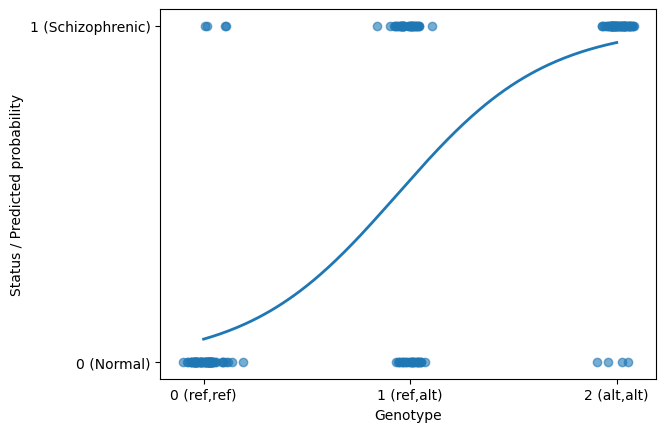

In [8]:
plt.figure()
# scatter raw data
plt.scatter(x_jitter, labels, alpha=0.6)

# logistic curve using fitted params
x_plot = np.linspace(0, 2, 200)
y_plot = logistic(x_plot, fit_beta_0, fit_beta_1)
plt.plot(x_plot, y_plot, linewidth=2)

plt.yticks([0,1], ["Control", "Case"])
plt.xlabel("Genotype")
plt.ylabel("Status / Predicted probability")
plt.yticks([0,1], ["0 (Normal)", "1 (Schizophrenic)"])
plt.xticks([0,1,2], ["0 (ref,ref)", "1 (ref,alt)","2 (alt,alt)"])

plt.show()

In [9]:
p_value = result.pvalues[1]
print(p_value)

3.235444087589193e-14
